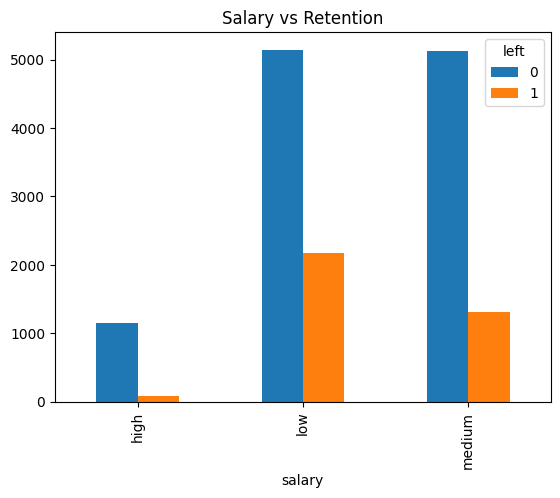

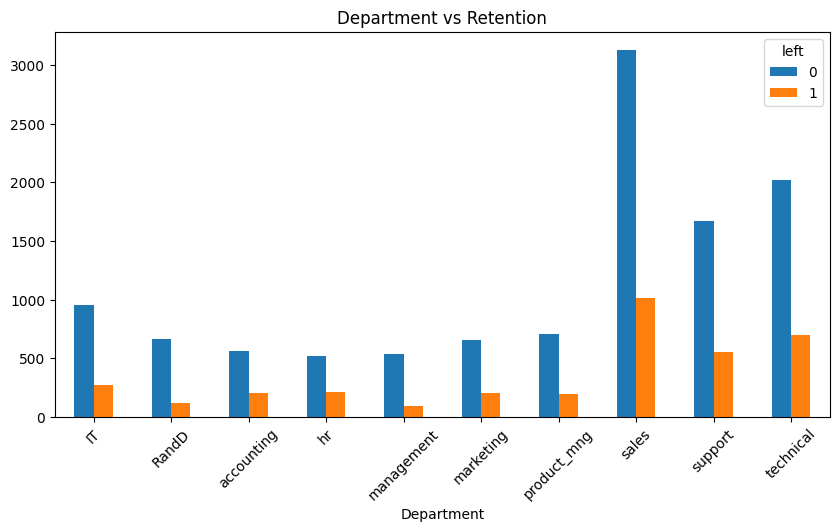

Accuracy (Sklearn Logistic Regression): 0.7662222222222222
Accuracy (Manual Logistic Regression): 0.7753333333333333


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


# =========================
# LOAD DATA
# =========================
df = pd.read_csv("/content/HR_comma_sep.csv")

# =========================
# BASIC EDA
# =========================

# Salary vs Retention
pd.crosstab(df.salary, df.left).plot(kind='bar')
plt.title("Salary vs Retention")
plt.show()

# Department vs Retention
pd.crosstab(df.Department, df.left).plot(kind='bar', figsize=(10,5))
plt.title("Department vs Retention")
plt.xticks(rotation=45)
plt.show()


# =========================
# DATA PREPROCESSING
# =========================

# Select important features
data = df[['satisfaction_level',
           'average_montly_hours',
           'promotion_last_5years',
           'salary']]

# Convert salary to dummy variables
data = pd.get_dummies(data, columns=['salary'], drop_first=True)

X = data.values
y = df['left'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature scaling (important for manual implementation)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# =====================================================
# 1️⃣ LOGISTIC REGRESSION USING SKLEARN (INBUILT)
# =====================================================
def logistic_regression_builtin(X_train, X_test, y_train, y_test):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print("Accuracy (Sklearn Logistic Regression):", acc)


# =====================================================
# 2️⃣ LOGISTIC REGRESSION FROM SCRATCH
# =====================================================
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def logistic_regression_manual(X_train, X_test, y_train, y_test, lr=0.01, epochs=1000):
    m, n = X_train.shape
    weights = np.zeros(n)
    bias = 0

    # Training using Gradient Descent
    for _ in range(epochs):
        linear_model = np.dot(X_train, weights) + bias
        y_pred = sigmoid(linear_model)

        dw = (1/m) * np.dot(X_train.T, (y_pred - y_train))
        db = (1/m) * np.sum(y_pred - y_train)

        weights -= lr * dw
        bias -= lr * db

    # Testing
    linear_test = np.dot(X_test, weights) + bias
    y_pred_test = sigmoid(linear_test)
    y_pred_class = [1 if i > 0.5 else 0 for i in y_pred_test]

    acc = accuracy_score(y_test, y_pred_class)
    print("Accuracy (Manual Logistic Regression):", acc)


# =========================
# RUN BOTH METHODS
# =========================
logistic_regression_builtin(X_train, X_test, y_train, y_test)
logistic_regression_manual(X_train, X_test, y_train, y_test)

Accuracy: 0.9523809523809523


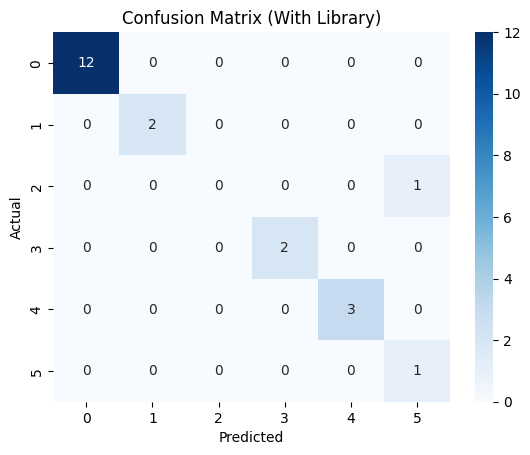

In [ ]:
# Logistic Regression USING sklearn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Load data
data = pd.read_csv('/content/zoo-data.csv')

# Remove animal name column
data = data.drop("animal_name", axis=1)

# Features and target
X = data.drop("class_type", axis=1)
y = data["class_type"] - 1   # make classes start from 0

# Split FIRST (important!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale AFTER splitting (correct way)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix (With Library)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()